# 02 — SAR First Look: Sentinel-1 RTC over the Marshall Fire AOI

**Goal:** See what Sentinel-1 SAR data looks like over the Marshall Fire area.

SAR (Synthetic Aperture Radar) looks nothing like a photograph. Instead of
recording reflected sunlight, the satellite transmits microwave pulses and
measures the strength of the returned signal (backscatter). Bright pixels
mean strong return (buildings, rough surfaces); dark pixels mean weak return
(smooth surfaces, water). The images are inherently noisy ("speckle").

We use the **sentinel-1-rtc** (Radiometrically Terrain Corrected) collection
from Planetary Computer. Unlike raw GRD, RTC products are:
- Geocoded as COGs with proper CRS (UTM)
- Terrain-corrected (no foreshortening/layover distortion)
- Calibrated to gamma-nought (γ0) in linear scale

This makes windowed reads and pre/post comparison straightforward.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import pystac_client
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

%matplotlib inline
plt.rcParams["figure.dpi"] = 120


def read_rtc_chip(item, asset_key, bbox_4326):
    """Read a Sentinel-1 RTC band windowed to a WGS84 bbox.

    RTC products are proper COGs with embedded CRS (UTM), so we
    reproject our WGS84 bbox into the raster's native CRS and window.
    """
    with rasterio.open(item.assets[asset_key].href) as src:
        native_bounds = transform_bounds("EPSG:4326", src.crs, *bbox_4326)
        window = from_bounds(*native_bounds, transform=src.transform)
        data = src.read(1, window=window).astype(np.float32)
        win_transform = src.window_transform(window)
        crs = src.crs
    return data, win_transform, crs

In [16]:
# ---------------------------------------------------------------------------
# Connect to Planetary Computer STAC and search for Sentinel-1 RTC scenes
# ---------------------------------------------------------------------------

# AOI_BBOX = [-105.23, 39.915, -105.12, 39.98]  # Marshall Fire area
AOI_BBOX = [-105.23, 39.915 , -105.12, 39.98]

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

# Pre-fire: November 2021
search_pre = catalog.search(
    collections=["sentinel-1-rtc"],
    bbox=AOI_BBOX,
    datetime="2021-11-01/2021-11-30",
)
items_pre = sorted(search_pre.items(), key=lambda x: x.datetime)

# Post-fire: January 2022
search_post = catalog.search(
    collections=["sentinel-1-rtc"],
    bbox=AOI_BBOX,
    datetime="2022-01-01/2022-01-31",
)
items_post = sorted(search_post.items(), key=lambda x: x.datetime)

print(f"Pre-fire RTC scenes (Nov 2021):  {len(items_pre)}")
for it in items_pre:
    orbit = it.properties.get("sat:orbit_state", "?")
    rel_orbit = it.properties.get("sat:relative_orbit", "?")
    print(f"  {it.id[:20]}...  {it.datetime.date()}  orbit={orbit}  rel={rel_orbit}")

print(f"\nPost-fire RTC scenes (Jan 2022): {len(items_post)}")
for it in items_post:
    orbit = it.properties.get("sat:orbit_state", "?")
    rel_orbit = it.properties.get("sat:relative_orbit", "?")
    print(f"  {it.id[:20]}...  {it.datetime.date()}  orbit={orbit}  rel={rel_orbit}")

# Pick scenes from the SAME relative orbit for valid comparison
pre_orbit = items_pre[0].properties.get("sat:relative_orbit")
matching_post = [it for it in items_post
                 if it.properties.get("sat:relative_orbit") == pre_orbit]
if matching_post:
    item_pre = items_pre[0]
    item_post = matching_post[0]
    print(f"\nMatched on relative orbit {pre_orbit}:")
else:
    # Fallback: just pick first of each
    item_pre = items_pre[0]
    item_post = items_post[0]
    print(f"\nNo orbit match — using first available:")

print(f"  Pre:  {item_pre.id}  ({item_pre.datetime.date()})")
print(f"  Post: {item_post.id} ({item_post.datetime.date()})")
print(f"  Assets: {list(item_pre.assets.keys())}")

Pre-fire RTC scenes (Nov 2021):  12
  S1A_IW_GRDH_1SDV_202...  2021-11-01  orbit=descending  rel=56
  S1B_IW_GRDH_1SDV_202...  2021-11-02  orbit=ascending  rel=151
  S1A_IW_GRDH_1SDV_202...  2021-11-08  orbit=descending  rel=158
  S1B_IW_GRDH_1SDV_202...  2021-11-09  orbit=ascending  rel=78
  S1B_IW_GRDH_1SDV_202...  2021-11-09  orbit=ascending  rel=78
  S1A_IW_GRDH_1SDV_202...  2021-11-13  orbit=descending  rel=56
  S1B_IW_GRDH_1SDV_202...  2021-11-14  orbit=ascending  rel=151
  S1A_IW_GRDH_1SDV_202...  2021-11-20  orbit=descending  rel=158
  S1B_IW_GRDH_1SDV_202...  2021-11-21  orbit=ascending  rel=78
  S1B_IW_GRDH_1SDV_202...  2021-11-21  orbit=ascending  rel=78
  S1A_IW_GRDH_1SDV_202...  2021-11-25  orbit=descending  rel=56
  S1B_IW_GRDH_1SDV_202...  2021-11-26  orbit=ascending  rel=151

Post-fire RTC scenes (Jan 2022): 5
  S1A_IW_GRDH_1SDV_202...  2022-01-07  orbit=descending  rel=158
  S1A_IW_GRDH_1SDV_202...  2022-01-12  orbit=descending  rel=56
  S1A_IW_GRDH_1SDV_202...  2022-0

## Read VV backscatter

RTC assets are proper COGs in UTM with gamma-nought (γ0) in linear scale.
We window-read to our AOI — no pixel-coordinate hacks needed.

In [17]:
# ---------------------------------------------------------------------------
# Read the pre-fire VV band, windowed to AOI
# ---------------------------------------------------------------------------

vv_pre_raw, transform_pre, crs = read_rtc_chip(item_pre, "vv", AOI_BBOX)

print(f"CRS:        {crs}")
print(f"Chip shape: {vv_pre_raw.shape}")
print(f"γ0 linear range: {np.nanmin(vv_pre_raw):.4f} -- {np.nanmax(vv_pre_raw):.4f}")
print(f"γ0 linear mean:  {np.nanmean(vv_pre_raw):.4f}")

CRS:        EPSG:32613
Chip shape: (723, 941)
γ0 linear range: 0.0018 -- 242.8497
γ0 linear mean:  0.1021


## Visualize with percentile stretch — expect speckle noise

SAR images have multiplicative speckle noise that makes them look "grainy".
We use a 2nd / 98th percentile stretch to improve contrast. RTC values
are in linear gamma-nought scale (not dB yet).

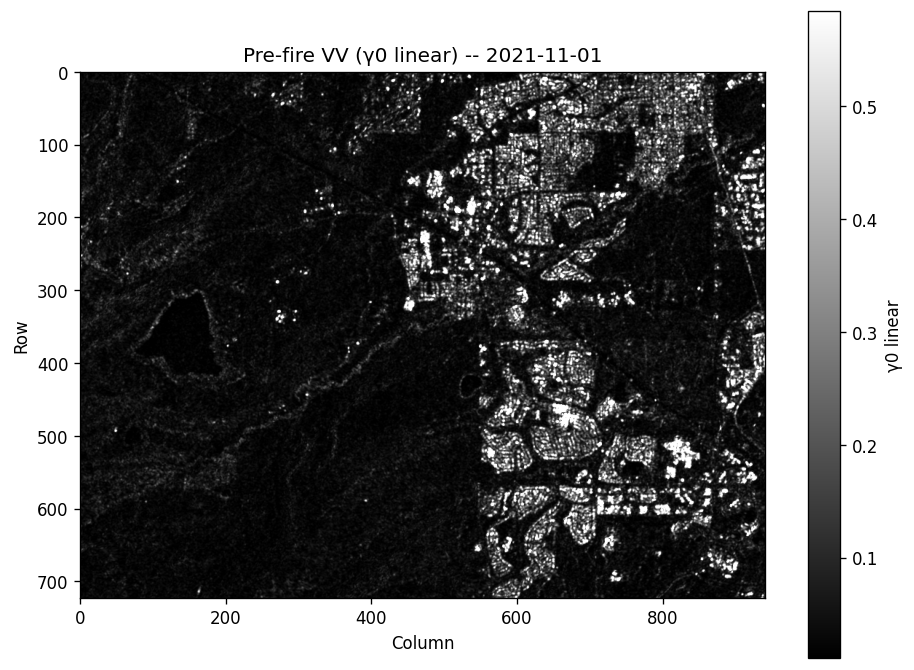

In [18]:
# ---------------------------------------------------------------------------
# Display the pre-fire VV chip with percentile stretch
# ---------------------------------------------------------------------------

vmin = np.nanpercentile(vv_pre_raw, 2)
vmax = np.nanpercentile(vv_pre_raw, 98)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(vv_pre_raw, cmap="gray", vmin=vmin, vmax=vmax)
ax.set_title(f"Pre-fire VV (γ0 linear) -- {item_pre.datetime.date()}")
ax.set_xlabel("Column")
ax.set_ylabel("Row")
plt.colorbar(im, ax=ax, label="γ0 linear", shrink=0.7)
plt.tight_layout()
plt.show()

## Pre/Post color composite

A side-by-side view is hard to compare visually. Instead we assign:
- **Red** = post-fire VV
- **Green** = pre-fire VV
- **Blue** = pre-fire VV (same as green)

In this encoding:
- **Red areas** = backscatter increased after fire (rare — debris, exposed soil)
- **Green/cyan areas** = backscatter decreased after fire (buildings destroyed, vegetation burned)
- **Gray/white** = no significant change

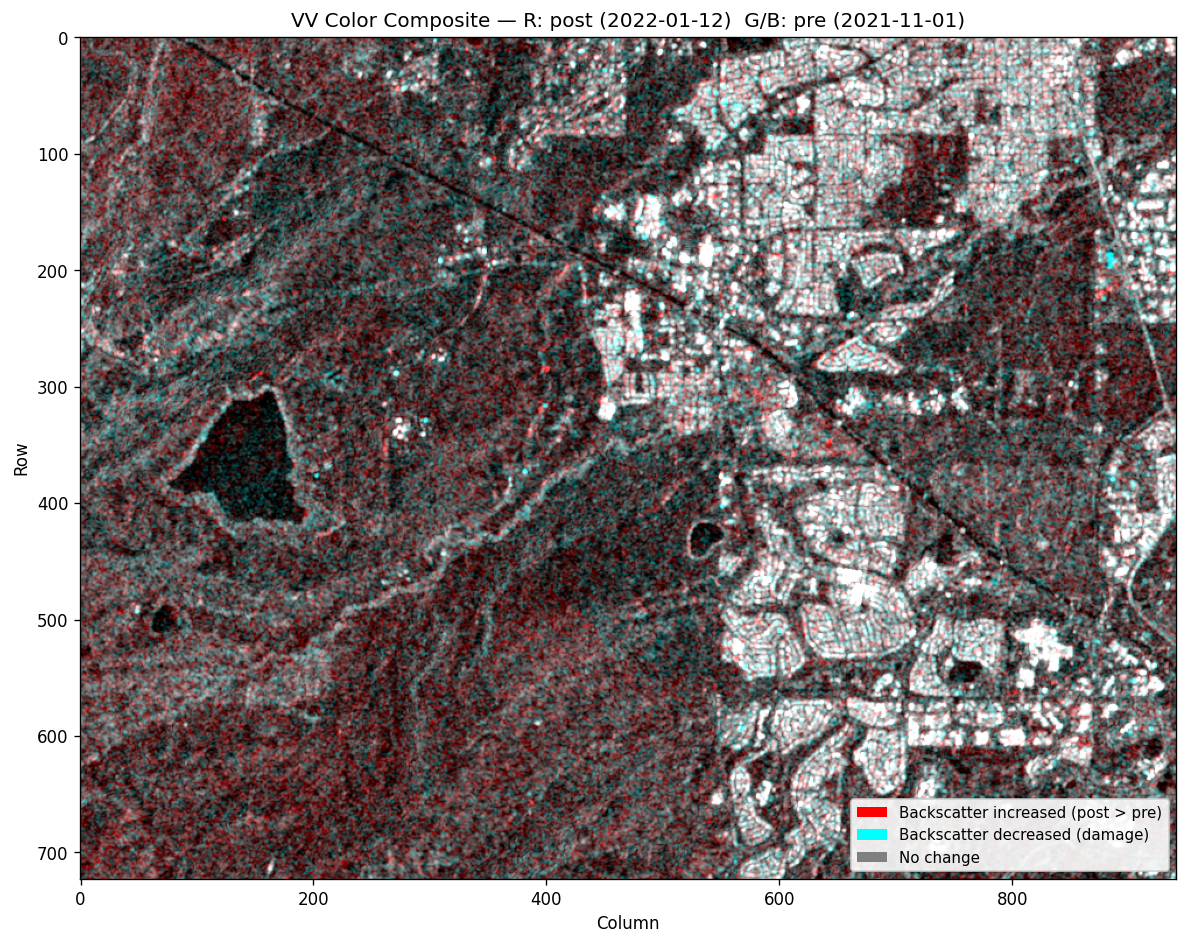

Chip shape: (723, 941)
Pre dB range:  [-19.2, -2.4]
Post-fire chip: (723, 941)


In [19]:
# ---------------------------------------------------------------------------
# Read post-fire VV and build RGB composite: R=post, G=pre, B=pre
# ---------------------------------------------------------------------------

vv_post_raw, transform_post, _ = read_rtc_chip(item_post, "vv", AOI_BBOX)

# Crop to matching extent
min_rows = min(vv_pre_raw.shape[0], vv_post_raw.shape[0])
min_cols = min(vv_pre_raw.shape[1], vv_post_raw.shape[1])
pre = vv_pre_raw[:min_rows, :min_cols]
post = vv_post_raw[:min_rows, :min_cols]

# Convert to dB for better visual contrast
def to_db(arr):
    a = arr.astype(np.float64)
    a = np.where(a > 0, a, 1e-30)
    return 10.0 * np.log10(a)

pre_db = to_db(pre)
post_db = to_db(post)

# Normalize to 0-1 using shared percentile stretch
vmin = np.nanpercentile(np.concatenate([pre_db.ravel(), post_db.ravel()]), 2)
vmax = np.nanpercentile(np.concatenate([pre_db.ravel(), post_db.ravel()]), 98)

def normalize(arr, lo, hi):
    return np.clip((arr - lo) / (hi - lo), 0, 1).astype(np.float32)

pre_norm = normalize(pre_db, vmin, vmax)
post_norm = normalize(post_db, vmin, vmax)

# RGB composite: R=post, G=pre, B=pre
rgb = np.stack([post_norm, pre_norm, pre_norm], axis=-1)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb)
ax.set_title(
    f"VV Color Composite — R: post ({item_post.datetime.date()})  "
    f"G/B: pre ({item_pre.datetime.date()})",
    fontsize=12,
)
ax.set_xlabel("Column")
ax.set_ylabel("Row")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="red", label="Backscatter increased (post > pre)"),
    Patch(facecolor="cyan", label="Backscatter decreased (damage)"),
    Patch(facecolor="gray", label="No change"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9,
          framealpha=0.9)

plt.tight_layout()
plt.show()

print(f"Chip shape: {rgb.shape[:2]}")
print(f"Pre dB range:  [{vmin:.1f}, {vmax:.1f}]")
print(f"Post-fire chip: {vv_post_raw.shape}")